Corentin Venet - Maxime Lacroix - Problem Set 1, Advanced Analytics of Finance

(a).
We use the Fama/French 3 Factors dataset (07/1926–06/2025) qnd Mkt-RF column gives the monthly market excess return in percent. We rename the first column, clean the data and plot the time series and histogram of the market excess returns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

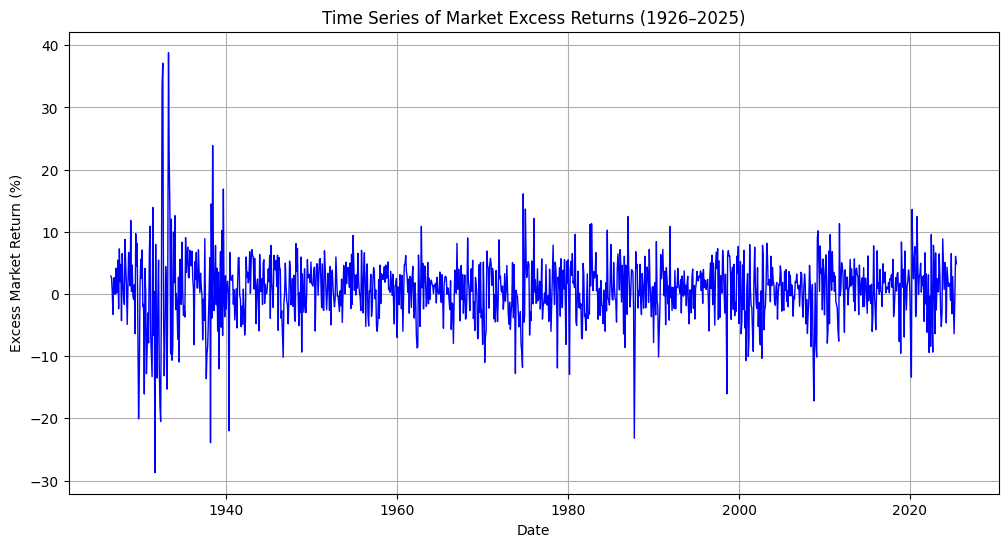

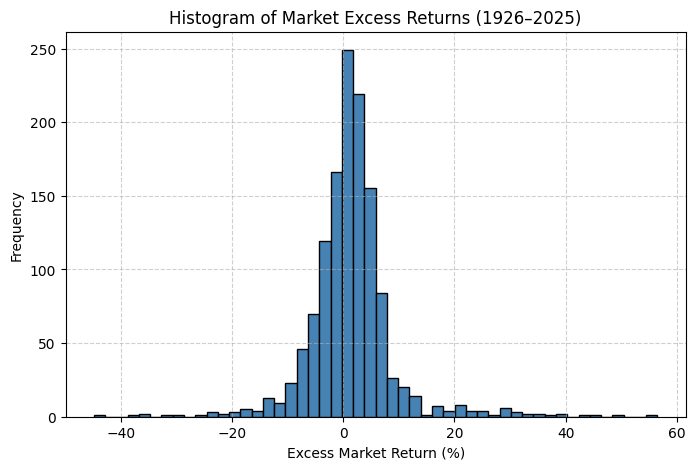

In [2]:
#Q1

df = pd.read_csv('F-F_Research_Data_Factors.csv')

df.rename(columns={df.columns[0]: "Date"}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m", errors="coerce")

for col in ["Mkt-RF", "SMB", "HML", "RF"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# --- Time series plot ---
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Mkt-RF"], color="blue", linewidth=1)
plt.title("Time Series of Market Excess Returns (1926–2025)")
plt.xlabel("Date")
plt.ylabel("Excess Market Return (%)")
plt.grid(True)
plt.show()

# --- Histogram ---
plt.figure(figsize=(8,5))
plt.hist(df["Mkt-RF"], bins=50, color="steelblue", edgecolor="black")
plt.title("Histogram of Market Excess Returns (1926–2025)")
plt.xlabel("Excess Market Return (%)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()



### Step 1. Model assumption

We assume

$$
r_t^e \sim \mathcal N(\mu, \sigma^2), \quad \sigma = 0.054 \text{ (known)}.
$$

### Step 2. Prior choice

We set

$$
\mu \sim \mathcal N(m_0, v_0^2).
$$

* **Prior mean $m_0$:** 0.5% per month (= 0.005 in decimals), consistent with long-run historical equity premium (\~6% annually).
* **Prior variance $v_0^2$:** chosen as $\sigma^2 / 24$. This makes the prior equivalent to \~24 months of data (two years), so it is informative but not dominating compared to \~1000 real observations.

### Step 3. Posterior derivation

By conjugacy, the posterior for μ after observing data through Dec-2015 is Normal:

$$
\mu \mid data \sim \mathcal N(m_T, v_T^2),
$$

with

$$
m_T = \frac{m_0 \sigma^2 + \bar r_T \, T \, v_0^2}{\sigma^2 + T v_0^2},
\quad
v_T^2 = \frac{v_0^2 \sigma^2}{\sigma^2 + T v_0^2}.
$$

### Step 4. One-month ahead posterior (for Jan-2016)

At the **start of January 2016**, before seeing the Jan return, the distribution of μ is:

$$
\boxed{ \mu \mid data \;\;\sim\;\; \mathcal N\!\Bigg(\frac{m_0 \sigma^2 + \bar r_T T v_0^2}{\sigma^2 + T v_0^2},\;\; \frac{v_0^2 \sigma^2}{\sigma^2 + T v_0^2} \Bigg) }
$$

This is exactly the “one-month ahead posterior for μ.”

* **Hyperparameters:** $m_0=0.005$, $v_0^2=\sigma^2/24$.
* **Posterior (Jan-2016):**

  $$
  \mu \mid data \sim \mathcal N(m_T, v_T^2),
  $$

  with $m_T,v_T^2$ given above.


In [3]:
# Restrict sample to 1926-07 through 2015-12
df_b = df[(df["Date"] >= "1926-07-01") & (df["Date"] <= "2015-12-31")].copy()
df_b["Mkt-RF"] = df_b["Mkt-RF"] / 100  # percent to decimal

T = len(df_b)
rbar = df_b["Mkt-RF"].mean()

# Prior hyperparameters
sigma = 0.054
m0 = 0.005
v0_sq = sigma**2 / 24

# Posterior parameters
mT = (m0 * sigma**2 + rbar * T * v0_sq) / (sigma**2 + T * v0_sq)
vT_sq = (v0_sq * sigma**2) / (sigma**2 + T * v0_sq)

print("Posterior mean for μ (Jan 2016):", mT)
print("Posterior std dev for μ (Jan 2026):", np.sqrt(vT_sq))


Posterior mean for μ (Jan 2016): 0.006450364298724955
Posterior std dev for μ (Jan 2026): 0.0016296434287653334


### Posterior predictive derivation

From the model, we can write the return as

$$
r_{t+1} = \mu + \sigma Z, \qquad Z \sim \mathcal N(0,1).
$$

After observing data through 12/2015, we know from part (b) that

$$
\mu \mid \text{data} \;\sim\; \mathcal N(m_T, v_T^2).
$$

Therefore, conditional on the data,

$$
r_{t+1} \mid \text{data} = \underbrace{\mu \mid \text{data}}_{\mathcal N(m_T,v_T^2)} \;+\; \underbrace{\sigma Z}_{\mathcal N(0,\sigma^2)}.
$$

Since the sum of two independent Normal random variables is Normal, we obtain

$$
\boxed{ \; r_{t+1} \mid \text{data} \;\sim\; \mathcal N\!\big(m_T,\; v_T^2 + \sigma^2\big) \; }.
$$


In [4]:
# Using mT and vT_sq computed in part (b)
pred_mean = mT
pred_var  = sigma**2 + vT_sq
pred_std  = np.sqrt(pred_var)

print("Predictive mean  E[r_{t+1}^e | data] =", round(pred_mean, 6))
print("Predictive stdev SD[r_{t+1}^e | data] =", round(pred_std, 6))


Predictive mean  E[r_{t+1}^e | data] = 0.00645
Predictive stdev SD[r_{t+1}^e | data] = 0.054025


Out-of-sample period: 114 months
OOS MSE: 22.461797975419557
OOS RMSE: 4.739387932573104


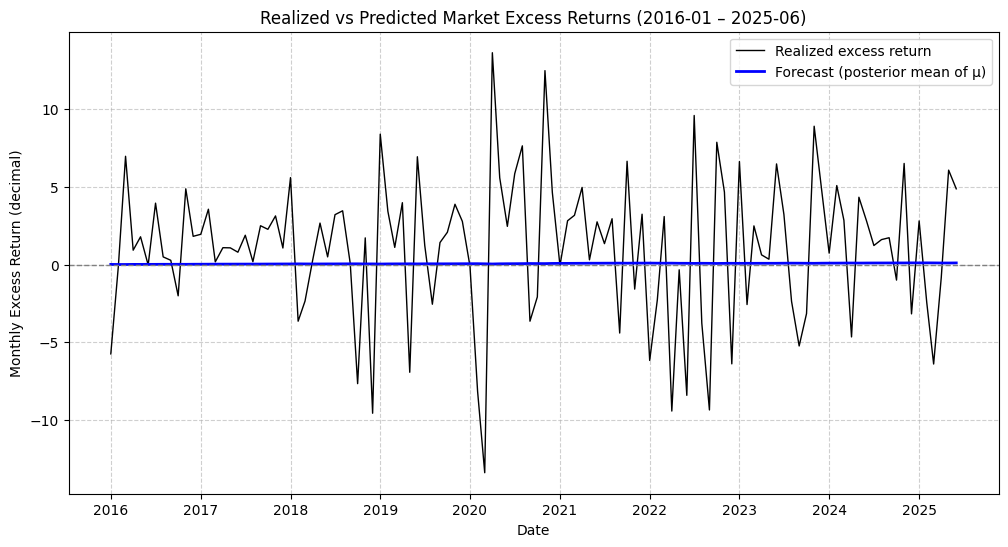

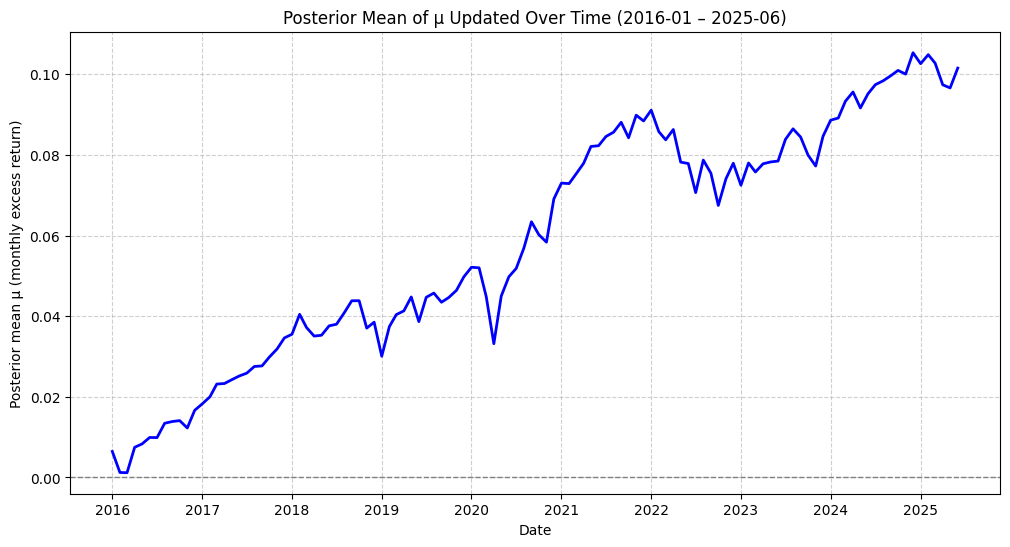

In [5]:
# -------------------------------
# Question (d): Bayesian forecasts 2016-01 to 2025-06
# -------------------------------

# Out-of-sample data
df_oos = df[(df["Date"] >= "2016-01-01") & (df["Date"] <= "2025-06-30")].copy()
df_oos = df_oos.dropna(subset=["Mkt-RF"]).sort_values("Date").reset_index(drop=True)

# Storage
forecasts, errors_sq, posterior_means = [], [], []

# Start from posterior after 2015 (computed in part b)
m_prev, v_prev = mT, vT_sq  

# Sequential forecasting and updating
for i, row in df_oos.iterrows():
    y_t = row["Mkt-RF"]

    # --- Forecast before seeing y_t: posterior mean of μ
    y_hat = m_prev
    forecasts.append({"Date": row["Date"], "forecast": y_hat, "realized": y_t})
    errors_sq.append((y_t - y_hat)**2)

    # Store posterior mean trajectory
    posterior_means.append({"Date": row["Date"], "m": m_prev})

    # --- Update posterior after observing y_t
    tau0 = 1.0 / v_prev
    tauL = 1.0 / sigma**2
    tauNew = tau0 + tauL
    v_new = 1.0 / tauNew
    m_new = (tau0 * m_prev + tauL * y_t) / tauNew

    # Prepare for next iteration
    m_prev, v_prev = m_new, v_new

# Out-of-sample MSE
oos_mse = np.mean(errors_sq)
oos_rmse = np.sqrt(oos_mse)

print("Out-of-sample period:", len(errors_sq), "months")
print("OOS MSE:", oos_mse)
print("OOS RMSE:", oos_rmse)

# Convert results to DataFrames
oos_df = pd.DataFrame(forecasts)
posterior_df = pd.DataFrame(posterior_means)

# -------------------------------
# Plots
# -------------------------------

# (1) Realized vs Forecasted returns
plt.figure(figsize=(12,6))
plt.plot(oos_df["Date"], oos_df["realized"], label="Realized excess return", color="black", linewidth=1)
plt.plot(oos_df["Date"], oos_df["forecast"], label="Forecast (posterior mean of μ)", color="blue", linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Realized vs Predicted Market Excess Returns (2016-01 – 2025-06)")
plt.xlabel("Date")
plt.ylabel("Monthly Excess Return (decimal)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# (2) Evolution of posterior mean of μ
plt.figure(figsize=(12,6))
plt.plot(posterior_df["Date"], posterior_df["m"], color="blue", linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Posterior Mean of μ Updated Over Time (2016-01 – 2025-06)")
plt.xlabel("Date")
plt.ylabel("Posterior mean μ (monthly excess return)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [ ]:

import statsmodels.api as sm

# 1) Training sample (ensure Mkt-RF is decimal already; if not, divide by 100 earlier)
train = df[(df["Date"] >= "1926-07-01") & (df["Date"] <= "2015-12-31")].copy()

# 2) Construct dependent variable r_{t+1}^e and regressor r_t^e (within sample)
train["y"] = train["Mkt-RF"].shift(-1)   # r_{t+1}
train["x"] = train["Mkt-RF"]             # r_t
train = train.dropna(subset=["y", "x"])  # drops last row (no t+1 inside train)

# 3) OLS with intercept
X = sm.add_constant(train["x"])          # const = a0, slope on r_t = a1
y = train["y"].values
ols_res = sm.OLS(y, X).fit()             # classical OLS

# 4) Extract coefficients, classical SEs, t-stats, R^2, and sigma_e^2
a0, a1 = ols_res.params["const"], ols_res.params["x"]
se_a0, se_a1 = np.sqrt(np.diag(ols_res.cov_params()))  # OLS (homoskedastic) SEs
t_a0, t_a1 = a0 / se_a0, a1 / se_a1
r2 = ols_res.rsquared
n = int(ols_res.nobs)
k = int(X.shape[1])                      # 2 parameters (const + slope)
sigma_e_sq = (ols_res.ssr) / (n - k)     # unbiased residual variance estimate

print(ols_res.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     12.97
Date:                Sun, 21 Sep 2025   Prob (F-statistic):           0.000331
Time:                        21:26:10   Log-Likelihood:                -3322.8
No. Observations:                1073   AIC:                             6650.
Df Residuals:                    1071   BIC:                             6659.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5750      0.165      3.489      0.0

# (f) Derivation under model (\*)

We estimated in (e):

$$
r_{t+1}^e = \hat a_0 + \hat a_1\, r_t^e + \varepsilon_{t+1}, 
\qquad \varepsilon_{t+1}\stackrel{iid}{\sim}\mathcal N(0,\hat\sigma^2),
$$

$$
r_{t+1}^e \mid r_t^e
= \hat a_0 + \hat a_1 r_t^e + \varepsilon_{t+1}.
$$

Because $\varepsilon_{t+1}\sim\mathcal N(0,\hat\sigma^2)$ and the first two terms are constant given $r_t^e$, the conditional distribution is Normal with

$$
\boxed{\;
r_{t+1}^e \mid r_t^e \;\sim\; \mathcal N\!\big(\,\hat\mu_{r,t},\ \hat\sigma^2_{r,t}\big),\qquad
\hat\mu_{r,t}=\hat a_0+\hat a_1 r_t^e,\;\;
\hat\sigma^2_{r,t}=\hat\sigma^2.\;
}
$$

## Accuracy metrics

* **Mean Squared Error (MSE):**

$$
\mathrm{MSE}=\frac{1}{N}\sum_{t\in \text{OOS}} e_{t+1}^2.
$$

* **Mean Absolute Error (MAE):**

$$
\mathrm{MAE}=\frac{1}{N}\sum_{t\in \text{OOS}} |e_{t+1}|.
$$

## Model comparison (to model $(\dagger)$ from part (d))

* Under **MSE**, the better model is the one with the **smaller OOS MSE**.
* If we **change the loss to MAE**, the ranking can change because MAE penalizes large forecast errors less heavily than MSE (MSE squares errors, overweighting outliers). Thus, if errors have outliers/heavy tails, the model with fewer extreme misses tends to look better under MAE even if MSE said otherwise.

Using OLS as true values: a0=0.574985, a1=0.109395, sigma=5.358586

Model (*) OOS months: 114
Model (*) OOS MSE   : 22.410955113414914
Model (*) OOS MAE   : 3.5509197286822842


<>:44: SyntaxWarning: invalid escape sequence '\h'
<>:44: SyntaxWarning: invalid escape sequence '\h'
/var/folders/lb/2vc7k14s3db649zm9644tb2c0000gn/T/ipykernel_20315/330014738.py:44: SyntaxWarning: invalid escape sequence '\h'
  plt.fill_between(dates, y_hat-1.96*pred_std, y_hat+1.96*pred_std, alpha=0.15, label="Predictive 95% band ($\hat\sigma$)")


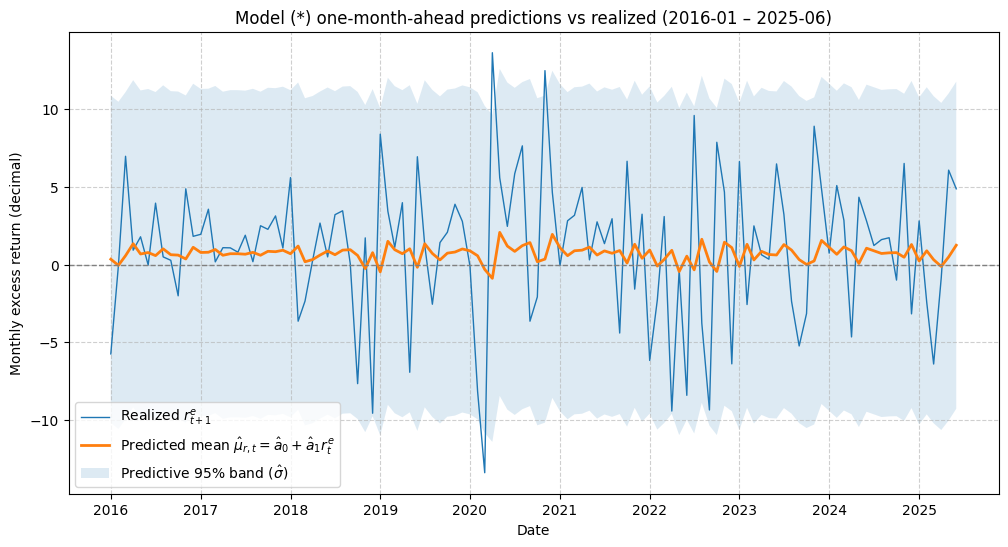


Model (†) OOS MSE   : 22.461797975419557
Model (†) OOS MAE   : 3.705286343964193
Better under MSE:  (*)
Better under MAE?  (*)


In [ ]:

# --- pull OLS estimates from (e) ---
a0 = float(ols_res.params["const"])
a1 = float(ols_res.params["x"])
n = int(ols_res.nobs)
k = 2
sigma2_hat = float(ols_res.ssr) / (n - k)  # innovation variance

print(f"Using OLS as true values: a0={a0:.6f}, a1={a1:.6f}, sigma={np.sqrt(sigma2_hat):.6f}")

# --- Build next-month target and align dates to the month being predicted ---
df = df.sort_values("Date").reset_index(drop=True).copy()
df["r_t"] = df["Mkt-RF"].astype(float)
df["r_tplus1"] = df["r_t"].shift(-1)         # realized next month
df["date_tplus1"] = df["Date"].shift(-1)     # date of next month

# --- OOS window: 2016-01 .. 2025-06 (use info at t to predict t+1) ---
oos = df[(df["date_tplus1"] >= "2016-01-01") & (df["date_tplus1"] <= "2025-06-30")].dropna(subset=["r_t","r_tplus1"]).copy()

# predictions and realized
oos["y_hat"] = a0 + a1 * oos["r_t"].values      # μ̂_{r,t} = a0 + a1 r_t
y_hat = oos["y_hat"].values
y_real = oos["r_tplus1"].values
dates  = oos["date_tplus1"].values

# --- Accuracy: MSE and MAE for model (*) ---
errors_star = y_real - y_hat
mse_star = float(np.mean(errors_star**2))
mae_star = float(np.mean(np.abs(errors_star)))

print("\nModel (*) OOS months:", len(oos))
print("Model (*) OOS MSE   :", mse_star)
print("Model (*) OOS MAE   :", mae_star)

# --- Plot realized vs predicted mean (and 95% band with σ̂) ---
plt.figure(figsize=(12,6))
plt.plot(dates, y_real, label="Realized $r_{t+1}^e$", linewidth=1)
plt.plot(dates, y_hat, label=r"Predicted mean $\hat\mu_{r,t}=\hat a_0+\hat a_1 r_t^e$", linewidth=2)
pred_std = np.sqrt(sigma2_hat)
plt.fill_between(dates, y_hat-1.96*pred_std, y_hat+1.96*pred_std, alpha=0.15, label="Predictive 95% band ($\hat\sigma$)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Model (*) one-month-ahead predictions vs realized (2016-01 – 2025-06)")
plt.xlabel("Date"); plt.ylabel("Monthly excess return (decimal)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# we’ll compute its MSE/MAE and compare.
try:
    # align the same OOS period
    bayes = oos_df[(oos_df["Date"] >= "2016-01-01") & (oos_df["Date"] <= "2025-06-30")].dropna(subset=["forecast","realized"]).copy()
    mse_dag = float(np.mean((bayes["realized"].values - bayes["forecast"].values)**2))
    mae_dag = float(np.mean(np.abs(bayes["realized"].values - bayes["forecast"].values)))
    print("\nModel (†) OOS MSE   :", mse_dag)
    print("Model (†) OOS MAE   :", mae_dag)

    better_mse = "(*)" if mse_star < mse_dag else "(†)" if mse_star > mse_dag else "tie"
    better_mae = "(*)" if mae_star < mae_dag else "(†)" if mae_star > mae_dag else "tie"
    print(f"Better under MSE:  {better_mse}")
    print(f"Better under MAE?  {better_mae}")
except Exception as _:
    pass  # Bayesian comparison not available; run your part-(d) code first if you want the head-to-head.




$$
\max_{\omega_t}\; 
\mathbb E_t\!\left[\omega_t(1+r_{t+1})+(1-\omega_t)(1+r_{f,t})\right]
-\frac{\alpha}{2}\,
\mathrm{Var}_t\!\left(\omega_t(1+r_{t+1})+(1-\omega_t)(1+r_{f,t})\right).
$$

Because $r_{f,t}$ is **known at time $t$**, it behaves like a constant:

* Use excess return $r^{e}_{t+1}=r_{t+1}-r_{f,t}$. Then

  $$
  \omega_t(1+r_{t+1})+(1-\omega_t)(1+r_{f,t})
  = (1+r_{f,t})+\omega_t r^{e}_{t+1}.
  $$
* Hence the objective becomes

  $$
  U_t(\omega_t)= (1+r_{f,t})
  + \omega_t\,\mathbb E_t[r^{e}_{t+1}]
  - \frac{\alpha}{2}\,\omega_t^{2}\,\mathrm{Var}_t(r^{e}_{t+1}),
  $$

  since $\mathrm{Var}_t( (1+r_{f,t})+\omega_t r^{e}_{t+1})=\omega_t^2 \mathrm{Var}_t(r^{e}_{t+1})$.

The constant $(1+r_{f,t})$ doesn’t affect the maximizer. Differentiate and set to zero:

$$
\frac{\partial U_t}{\partial \omega_t}
= \mathbb E_t[r^{e}_{t+1}] - \alpha\,\omega_t\,\mathrm{Var}_t(r^{e}_{t+1}) = 0
\quad \Longrightarrow \quad
\boxed{\;
\omega_t^{\star}=\frac{\mathbb E_t[r^{e}_{t+1}]}{\alpha\,\mathrm{Var}_t(r^{e}_{t+1})}\; }.
$$

/var/folders/lb/2vc7k14s3db649zm9644tb2c0000gn/T/ipykernel_20315/183650060.py:44: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  preds.append([t1, row["rf_dec"], float(df.loc[df["date"] == t1, "re"]),


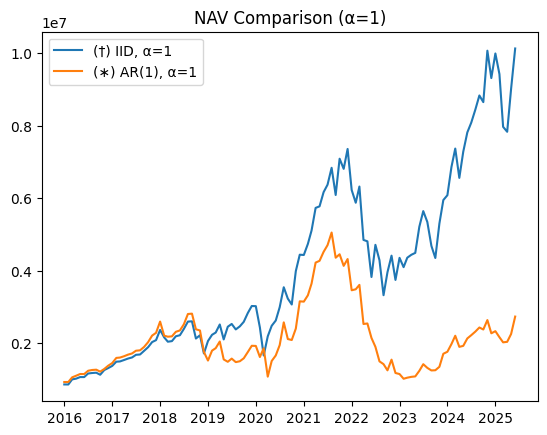

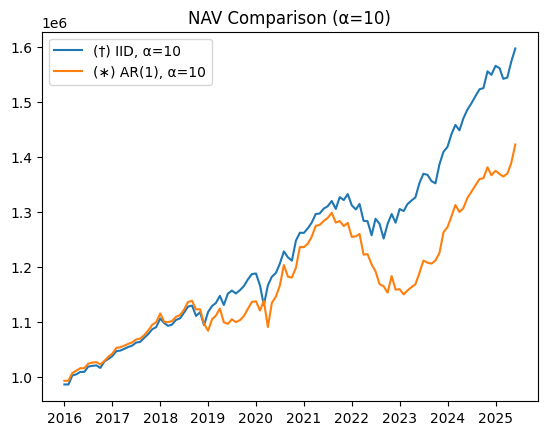

,CAGR,Vol,Mean,Sharpe
"IID, α=1",0.2956,0.3882,0.3227,0.8313
"IID, α=10",0.0520,0.0391,0.0501,1.2808
"AR1, α=1",0.1201,0.4307,0.2023,0.4698
"AR1, α=10",0.0385,0.0434,0.0381,0.8776


In [10]:
# =====================
# HW1 Question 4(h)
# =====================

import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---- Prior (same notation as earlier in notebook) ----
sigma_known = 0.054
sigma2 = sigma_known**2
mu0 = 0.05      # prior mean
v0  = 0.05**2   # prior variance of μ

# ---- Fit AR(1) on training sample ----
train_re = train["re"].values
X = sm.add_constant(train_re[:-1])
ols = sm.OLS(train_re[1:], X).fit()
a0_hat, a1_hat = ols.params
sigma2_e_hat = ols.mse_resid

# ---- Decision timeline ----
def add_months(ts, n):
    y = ts.year + (ts.month-1+n)//12
    m = (ts.month-1+n)%12 + 1
    return pd.Timestamp(y, m, 1)

oos = oos.copy()
oos["t_decision"] = oos["date"].apply(lambda d: add_months(d, -1))

# ---- Generate predictions for both models ----
preds = []
for _, row in oos.iterrows():
    t, t1 = row["t_decision"], row["date"]
    
    # IID (†): Bayesian update using all data <= t
    hist = df[df["date"] <= t]["re"].values
    mu_n, v_n = posterior_mu_known_sigma(hist, mu0, v0, sigma2)
    mean_dag, var_dag = mu_n, sigma2 + v_n
    
    # AR(1) (∗): use last observed re_t
    re_t = float(df.loc[df["date"] == t, "re"].values[-1])
    mean_star, var_star = a0_hat + a1_hat*re_t, sigma2_e_hat
    
    preds.append([t1, row["rf_dec"], float(df.loc[df["date"] == t1, "re"]),
                  mean_dag, var_dag, mean_star, var_star])

pred = pd.DataFrame(preds, columns=["date","rf","re_realized",
                                    "mean_dag","var_dag","mean_star","var_star"])

# ---- NAV calculation ----
def compute_nav(pred, alpha, mean_col, var_col):
    out = pred.copy()
    out["omega"] = out[mean_col] / (alpha * out[var_col])
    out["gross"] = 1 + out["rf"] + out["omega"]*out["re_realized"]
    out["nav"] = 1_000_000 * out["gross"].cumprod()
    return out

navs = {
    ("IID",1):  compute_nav(pred,1,"mean_dag","var_dag"),
    ("IID",10): compute_nav(pred,10,"mean_dag","var_dag"),
    ("AR1",1):  compute_nav(pred,1,"mean_star","var_star"),
    ("AR1",10): compute_nav(pred,10,"mean_star","var_star"),
}

# ---- Plots ----
plt.figure()
plt.plot(navs[("IID",1)]["date"], navs[("IID",1)]["nav"], label="(†) IID, α=1")
plt.plot(navs[("AR1",1)]["date"], navs[("AR1",1)]["nav"], label="(∗) AR(1), α=1")
plt.legend(); plt.title("NAV Comparison (α=1)"); plt.show()

plt.figure()
plt.plot(navs[("IID",10)]["date"], navs[("IID",10)]["nav"], label="(†) IID, α=10")
plt.plot(navs[("AR1",10)]["date"], navs[("AR1",10)]["nav"], label="(∗) AR(1), α=10")
plt.legend(); plt.title("NAV Comparison (α=10)"); plt.show()

# ---- Performance summary ----
def perf(nav):
    r = nav["gross"] - 1
    n = len(r)
    cagr = (nav["nav"].iloc[-1]/nav["nav"].iloc[0])**(12/n) - 1
    vol = r.std()*np.sqrt(12)
    mean_ann = r.mean()*12
    return dict(CAGR=cagr, Vol=vol, Mean=mean_ann, Sharpe=mean_ann/vol)

summary = pd.DataFrame({f"{m}, α={a}": perf(df) for (m,a),df in navs.items()}).T
display(summary.round(4))
